# Previous check of GPU availability
Checking tf version for the compatibility of GPU usage.

In [1]:
import tensorflow as tf

# Check TensorFlow version for compatibility
print("TensorFlow version:", tf.__version__)

# List available GPUs for GPU acceleration
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("GPUs:", physical_devices)
    try:
        # Enable dynamic memory growth (best practice to avoid GPU memory errors)
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    except Exception as e:
        pass
else:
    print("No GPU found, using CPU.")

TensorFlow version: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load data and importing libraries
Load necesary data from Load_manipulate.ipynb and importing libraries to work

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt  # Keras Tuner for hyperparameter tuning

# Import necessary libraries for model evaluation
from sklearn.model_selection import cross_val_score, KFold 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, make_scorer, precision_score

# Load the OHE molecules
data_combined = pd.read_csv('OHE_data.csv')

# Separate x_data and y_data of the OHE_data
x_data = data_combined.iloc[:, :-1].values  # All columns except the last one
y_data = data_combined['target'].values    # The last column

# Verify the shapes
print(f"x_data shape: {x_data.shape}")
print(f"y_data shape: {y_data.shape}")

# Define the number of atom types and positions
# These should match the one-hot encoding used in the data
n_atom_types = 5          # e.g., 5 atom types (H, F, Cl, Br, I)
n_pos = 16                # number of possible positions (16)
n_features = n_atom_types * n_pos  # total one-hot features

# Load Rmin_abs_mean and Rmin_abs_std
stats = pd.read_csv('Rmin_stats.csv')
Rmin_abs_mean = stats['Rmin_abs_mean'].values[0]
Rmin_abs_std = stats['Rmin_abs_std'].values[0]

# Verify the values extracted from Rmin_stats.csv
print(f"Rmin_abs_mean: {Rmin_abs_mean}")
print(f"Rmin_abs_std: {Rmin_abs_std}")

x_data shape: (1183, 80)
y_data shape: (1183,)
Rmin_abs_mean: -299.8190789518174
Rmin_abs_std: 122.410091966645


# Shuffling and splitting the data for training and test

In [3]:
# Library for data preprocessing
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

#Since we're going to use C-V the shuffle() step is necessary to ensure that the data is randomly ordered before splitting into folds.
x_data, y_data = shuffle(x_data, y_data, random_state=39)
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

# Save the train and test data to CSV files
x_train_df = pd.DataFrame(x_train, columns=[f'feature_{i}' for i in range(x_train.shape[1])])
y_train_df = pd.DataFrame(y_train, columns=['target'])
x_test_df = pd.DataFrame(x_test, columns=[f'feature_{i}' for i in range(x_test.shape[1])])
y_test_df = pd.DataFrame(y_test, columns=['target'])

x_train_df.to_csv('x_train.csv', index=False)
y_train_df.to_csv('y_train.csv', index=False)
x_test_df.to_csv('x_test.csv', index=False)
y_test_df.to_csv('y_test.csv', index=False)

# Print dataset shape for verification
print(f"Training examples: {len(x_train)}, Test examples: {len(x_test)}")
print(f"Input feature shape: {x_train.shape}, Target shape: {y_train.shape}")

Training examples: 946, Test examples: 237
Input feature shape: (946, 80), Target shape: (946,)


# Architecture of our model
This architecture is designed to respect molecular symmetries and efficiently model both local (1-body) and global (N-body) interactions.

In [4]:
# Define a model-building function for Keras Tuner
def build_model(hp):
    inputs = tf.keras.Input(shape=(n_features,), name='Molecule')
    inputs_aux = tf.keras.layers.Reshape((n_features, 1), name='Molecule_aux')(inputs) # Reshape for 1D cropping
    
    # 1-body part (fixed as defined above, using weight sharing)
    single_position = []
    
    for i in range(n_pos):
        left_crop = i * n_atom_types
        right_crop = n_features - (left_crop + n_atom_types)
        pos_i = tf.keras.layers.Cropping1D(cropping=(left_crop, right_crop))(inputs_aux)
        single_position.append(pos_i)
    
    # Define 1-body submodel (linear layer without bias for each position)
    def make_1body_model():
        inp = tf.keras.Input(shape=(n_atom_types,))
        out = tf.keras.layers.Dense(1, use_bias=False, kernel_initializer='random_normal')(inp) # Linear transformation without bias
        return tf.keras.Model(inp, out)

    # Create one 1-body model per unique position (here 8 unique positions due to symmetry)
    models_1b = [make_1body_model() for _ in range(n_pos // 2)]

    # Apply each 1-body model to the corresponding positions
    outputs_1b = []
    
    for i in range(n_pos // 2):
        outputs_1b.append(models_1b[i](single_position[i]))

    # For the second half of the positions, use the corresponding model from the first half to ensure symmetry
    for i in range(n_pos // 2, n_pos):
        outputs_1b.append(models_1b[n_pos - 1 - i](single_position[i]))
    
    # N-Body term: combine 1-body outputs to capture higher-order interactions
    # Concatenate the 1-body outputs for the molecule in normal and reversed order (to enforce invariance under reversal)
    x = tf.keras.layers.Concatenate()(outputs_1b)
    x_rev = tf.keras.layers.Concatenate()(list(reversed(outputs_1b)))
    
    # N-body part hyperparameters
    units = hp.Choice('units', [128, 256, 512])
    layers = hp.Choice('layers', [1, 2, 3, 4])
    dropout = hp.Choice('dropout_rate', [0.0, 0.3, 0.5])
    lr = hp.Choice('learning_rate',[1e-2, 5e-3, 1e-3])
    # Define the N-body interaction model (will be applied to both x and x_rev)
    def build_nbody_model(units=512, layers=1, dropout_rate=0.5):
        """Builds a small feed-forward network for N-body interactions."""
        inputs_nb = tf.keras.Input(shape=(n_pos,))
        nn = tf.keras.layers.Dense(units, activation='relu', 
                                kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                                kernel_initializer='random_normal', bias_initializer='zeros')(inputs_nb)
        nn = tf.keras.layers.Dropout(dropout_rate)(nn)
        if layers > 1:
            # If more than one layer is desired
            for _ in range(layers - 1):
                nn = tf.keras.layers.Dense(units, activation='relu', 
                                        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                                        kernel_initializer='random_normal', bias_initializer='zeros')(nn)
                nn = tf.keras.layers.Dropout(dropout_rate)(nn)
        output_nb = tf.keras.layers.Dense(1)(nn)
        return tf.keras.Model(inputs_nb, output_nb, name='N-body')
    
    # Build N-body submodel with the hyperparameters
    nbody_net = build_nbody_model(units=units, layers=layers, dropout_rate=dropout)
    out1 = nbody_net(x)
    out2 = nbody_net(x_rev)
    total_out = tf.keras.layers.Add()([out1, out2])
    model = tf.keras.Model(inputs, total_out)
    
    # Compile model with a tunable learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mean_absolute_error')
    return model

# Hyperparameter tunning
Search for the most suitable hyperparameters to avoid problems like over/under-fitting or unstable trainings, using the complexity of our model relationships as a bias.

In [5]:
# Set up Hyperband tuner to search hyperparameters
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',        # Objective to optimize
    max_epochs=100,              # maximum epochs to train for each model
    factor=3,                    # Hyperband reduction factor
    directory='kt_dir',          # Directory to save the results
    project_name='Rmin_Invariant_Nbody_Tuning' # Project name for Keras Tuner
)

# Use early stopping during hyperparameter search to curtail long trainings
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Run the hyperparameter search
tuner.search(x_train, y_train, validation_split=0.1, epochs=300, batch_size=8, callbacks=[stop_early], verbose=2)

# Get the optimal hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters: units={best_hp.get('units')}, layers={best_hp.get('layers')}, "
      f"dropout_rate={best_hp.get('dropout_rate')}, learning_rate={best_hp.get('learning_rate')}")

# Save best_hp to a JSON file
import json

best_hp_dict = best_hp.values  # Extract the hyperparameters as a dictionary
with open("best_hp.json", "w") as f:
    json.dump(best_hp_dict, f)


Reloading Tuner from kt_dir\Rmin_Invariant_Nbody_Tuning\tuner0.json
Best hyperparameters: units=256, layers=3, dropout_rate=0.3, learning_rate=0.005


# Prediction vs. True values plot
Plot for the visualization of the convergence of true and predicted data.

In [6]:
def plot_PredvsTrue(y_true_test, y_pred_test, y_true_train, y_pred_train, i_CV=0):
    plt.figure(figsize=(3, 3), dpi=200)
    plt.title(f"Regression of R, CV {i_CV}", fontsize=10)

    # Improved Axis Scaling
    p1 = min(y_true_test)
    p2 = max(y_true_test)
    plt.plot([p1, p2], [p1, p2], 'r--', label="Exact")

    # Scatter Plots
    sns.scatterplot(x=y_true_train, y=y_pred_train, color="orange", s=8, label="Train")
    sns.scatterplot(x=y_true_test, y=y_pred_test, color="blue", s=8, label="Test")

    plt.xlabel("True", fontsize=12)
    plt.ylabel("Pred", fontsize=12)
    plt.legend(loc="upper left", fontsize=10)
    plt.grid(False)

    """# Save Figure
    plt.savefig(f"regression_cv_{i_CV}.png", dpi=300, bbox_inches="tight")
    plt.show()"""

# Mean Absolute Value vs. n_subs
Computes and visualizes the error as a function of the number of substitutes.

In [7]:
#function to compute error for different nsubs on test set
def error_vs_nsubs(x_test, y_pred_test, y_true_test):
    # Vectorized computation of number of substitutes per sample
    nsubs_test = np.sum(x_test[:, ::n_atom_types] == 0, axis=1)

    # Create DataFrame for easy grouping
    df = pd.DataFrame({"nsubs": nsubs_test, "error": np.abs(y_pred_test - y_true_test)})
    
    # Compute MAE per substitute group
    error_nsubs = df.groupby("nsubs")["error"].mean().reindex(range(7), fill_value=0).values
    num_subs = df["nsubs"].value_counts().reindex(range(7), fill_value=0).values

    # Remove the 0 index (no substitutes)
    error_nsubs = error_nsubs[1:]
    num_subs = num_subs[1:]

    # Print number of samples per group
    print("Number of samples per n_subs (1-6):", num_subs)
    print("Mean Absolute Error per n_subs (1-6):", error_nsubs)

    # Plot MAE vs nsubs (starting from 1)
    plt.figure(figsize=(5, 4))
    sns.barplot(x=np.arange(1, 7), y=error_nsubs)
    plt.xlabel("Number of Substitutes (n_subs)", fontsize=14)
    plt.ylabel("Mean Absolute Error (MAE)", fontsize=14)
    plt.ylim([0, 100])
    plt.grid(False)
    plt.show()

    return error_nsubs

# Cross Validation
Implementation of fold-cross-validation to evaluate the model's performance.

34/34 [==============================] - 0s 2ms/step
Fold 1/10
  Train MAE: 54.9502, Train RMSE: 71.7669, Train MAPE: 20.79%, Train R²: 0.6600
  Test  MAE: 63.6580, Test  RMSE: 83.2994, Test  MAPE: 24.81%, Test  R²: 0.4750
--------------------------------------------------------------------------------
Number of samples per n_subs (1-6): [ 3 14 16 24 28 34]
Mean Absolute Error per n_subs (1-6): [57.93421296 58.91174314 59.70193563 62.14158233 57.7417032  73.92186774]


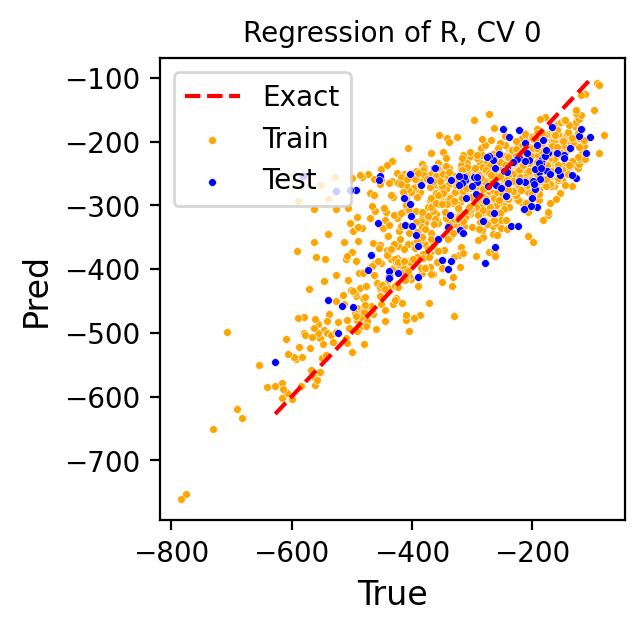

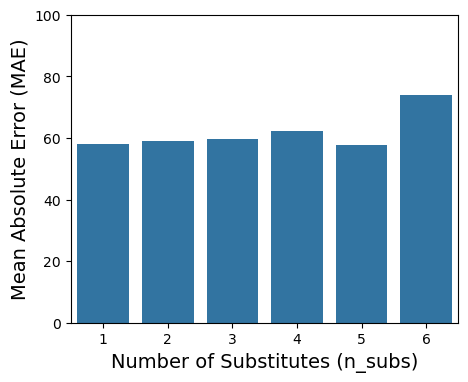

34/34 [==============================] - 0s 2ms/step
Fold 2/10
  Train MAE: 50.5775, Train RMSE: 68.7921, Train MAPE: 18.23%, Train R²: 0.6788
  Test  MAE: 64.1107, Test  RMSE: 81.3649, Test  MAPE: 23.72%, Test  R²: 0.6057
--------------------------------------------------------------------------------
Number of samples per n_subs (1-6): [ 0 17 28 28 11 35]
Mean Absolute Error per n_subs (1-6): [ 0.         54.39317698 69.15108609 58.6571944  76.7795128  65.1796156 ]


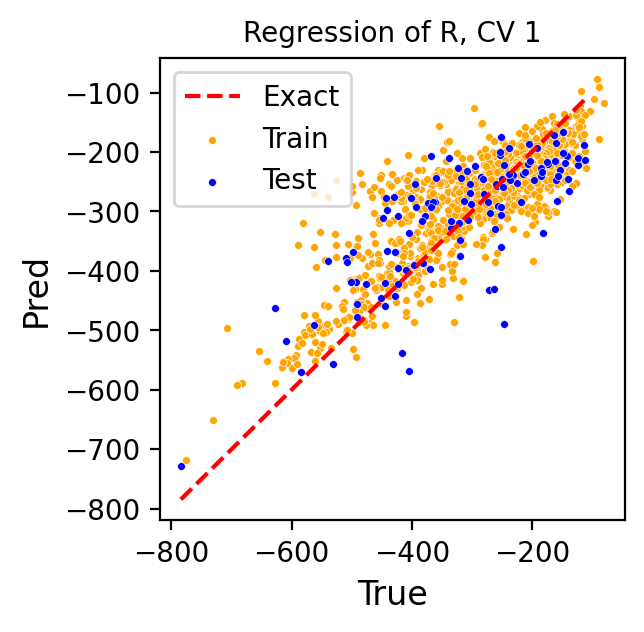

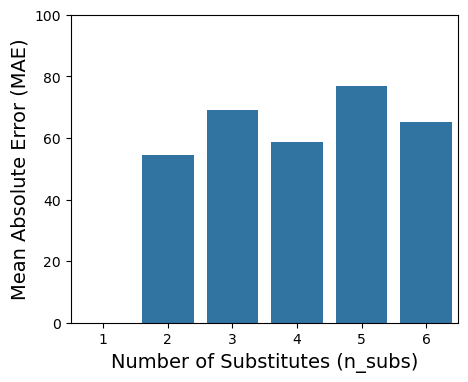

34/34 [==============================] - 0s 2ms/step
Fold 3/10
  Train MAE: 50.5142, Train RMSE: 69.2250, Train MAPE: 18.66%, Train R²: 0.6738
  Test  MAE: 56.1445, Test  RMSE: 75.3309, Test  MAPE: 19.50%, Test  R²: 0.6739
--------------------------------------------------------------------------------
Number of samples per n_subs (1-6): [ 5 11 23 21 20 39]
Mean Absolute Error per n_subs (1-6): [23.56383294 44.60694424 46.76166921 51.91369509 64.31750572 67.19601701]


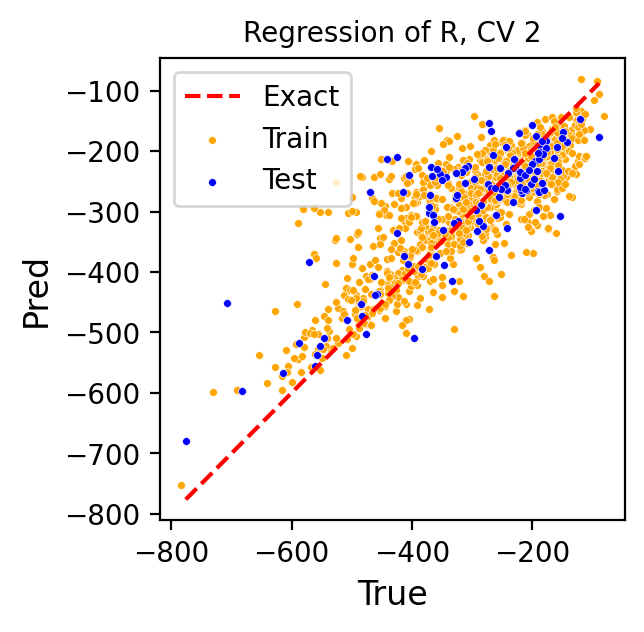

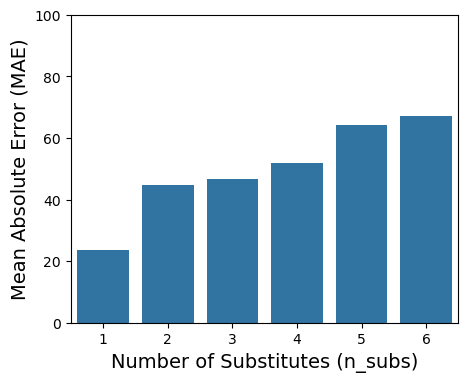

34/34 [==============================] - 0s 2ms/step
Fold 4/10
  Train MAE: 51.3010, Train RMSE: 71.2483, Train MAPE: 18.17%, Train R²: 0.6679
  Test  MAE: 64.6375, Test  RMSE: 82.2981, Test  MAPE: 23.88%, Test  R²: 0.4365
--------------------------------------------------------------------------------
Number of samples per n_subs (1-6): [ 1 16 17 24 21 39]
Mean Absolute Error per n_subs (1-6): [84.69927393 41.80237856 55.22709549 76.2360474  85.63261563 59.15066875]


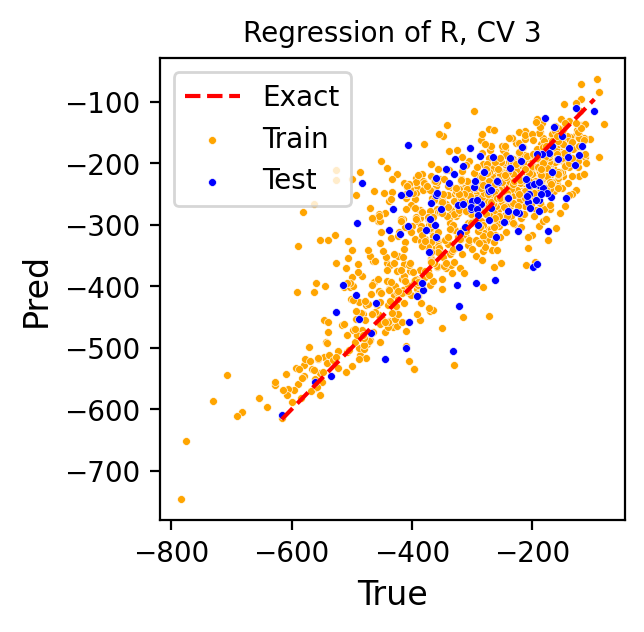

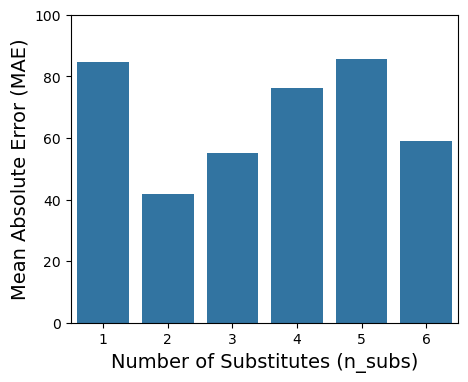

34/34 [==============================] - 0s 2ms/step
Fold 5/10
  Train MAE: 57.3642, Train RMSE: 76.5671, Train MAPE: 20.07%, Train R²: 0.6035
  Test  MAE: 50.1615, Test  RMSE: 70.1269, Test  MAPE: 18.29%, Test  R²: 0.7043
--------------------------------------------------------------------------------
Number of samples per n_subs (1-6): [ 4 22 22 12 22 36]
Mean Absolute Error per n_subs (1-6): [ 9.75386749 49.31141385 64.67909606 76.20800989 57.69716225 33.01148463]


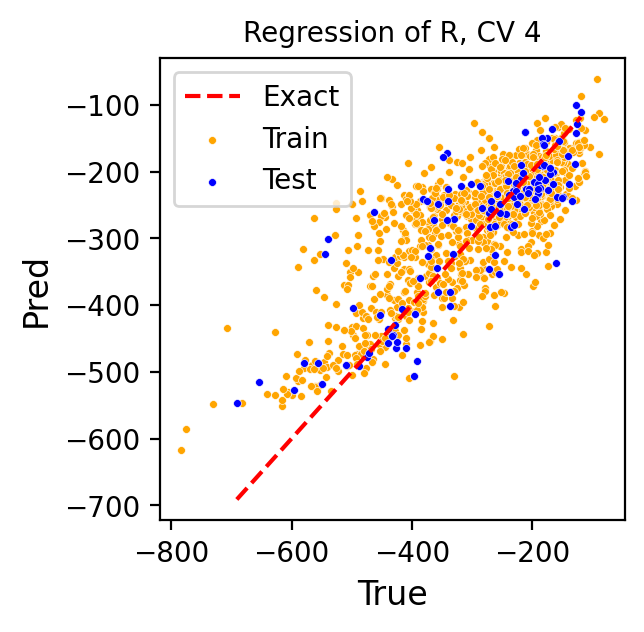

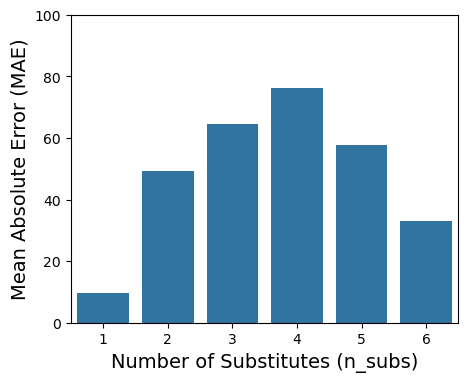

34/34 [==============================] - 0s 2ms/step
Fold 6/10
  Train MAE: 55.8975, Train RMSE: 74.3013, Train MAPE: 20.21%, Train R²: 0.6347
  Test  MAE: 64.9069, Test  RMSE: 85.9224, Test  MAPE: 22.96%, Test  R²: 0.4604
--------------------------------------------------------------------------------
Number of samples per n_subs (1-6): [ 3  7 24 12 24 48]
Mean Absolute Error per n_subs (1-6): [11.11151777 45.20320806 62.08964026 43.71241738 72.30224208 74.15214616]


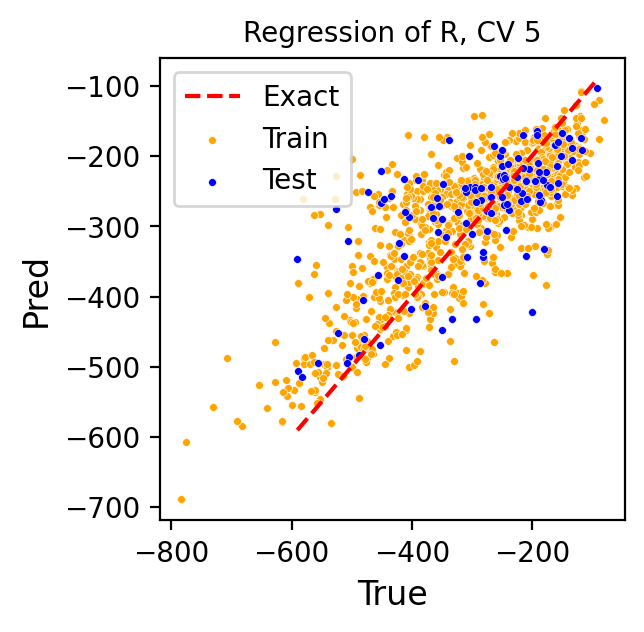

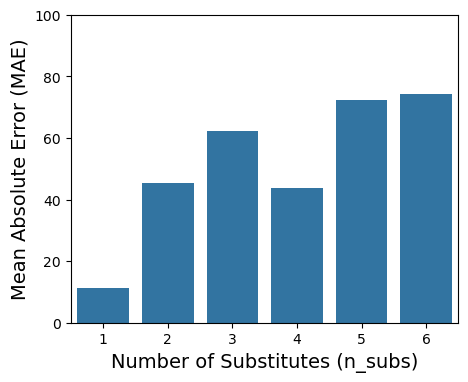

34/34 [==============================] - 0s 2ms/step
Fold 7/10
  Train MAE: 53.7972, Train RMSE: 71.3789, Train MAPE: 19.64%, Train R²: 0.6611
  Test  MAE: 64.1653, Test  RMSE: 81.3516, Test  MAPE: 23.78%, Test  R²: 0.5400
--------------------------------------------------------------------------------
Number of samples per n_subs (1-6): [ 2 16 20 22 22 36]
Mean Absolute Error per n_subs (1-6): [54.48043274 62.08566929 73.3791676  74.12421656 57.5487179  58.46636037]


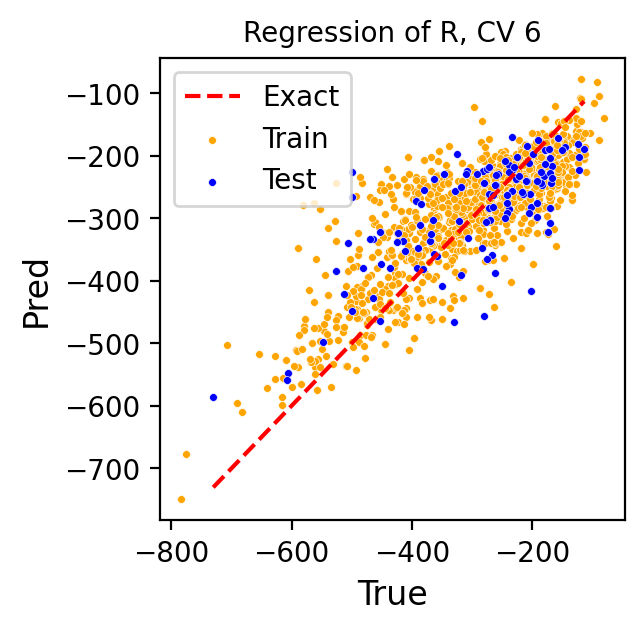

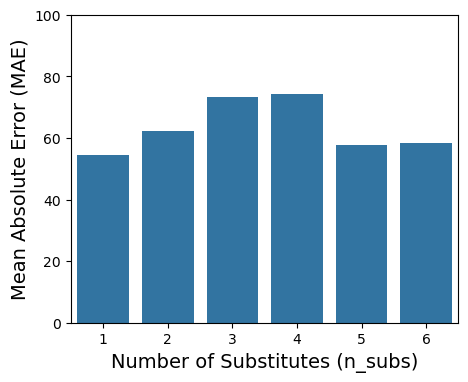

34/34 [==============================] - 0s 2ms/step
Fold 8/10
  Train MAE: 49.7560, Train RMSE: 68.2788, Train MAPE: 17.76%, Train R²: 0.6884
  Test  MAE: 62.3452, Test  RMSE: 86.7982, Test  MAPE: 21.18%, Test  R²: 0.4992
--------------------------------------------------------------------------------
Number of samples per n_subs (1-6): [ 3 13 19 25 23 35]
Mean Absolute Error per n_subs (1-6): [29.83223952 40.92926661 52.8940738  68.5210947  59.17253791 75.89058739]


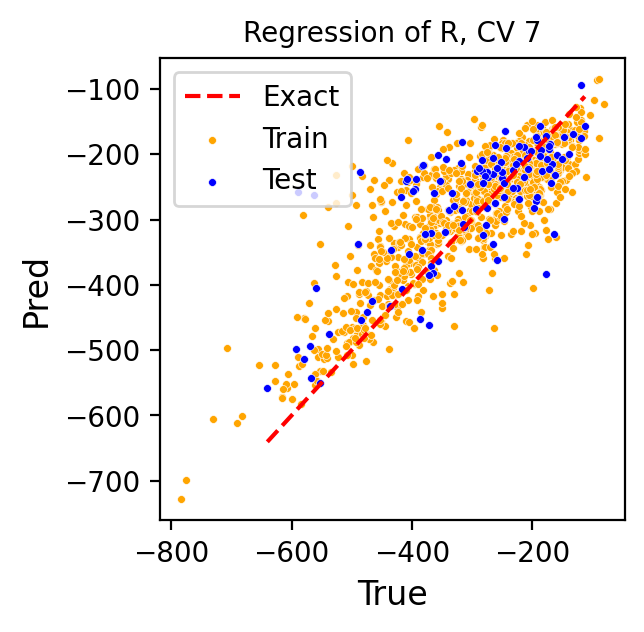

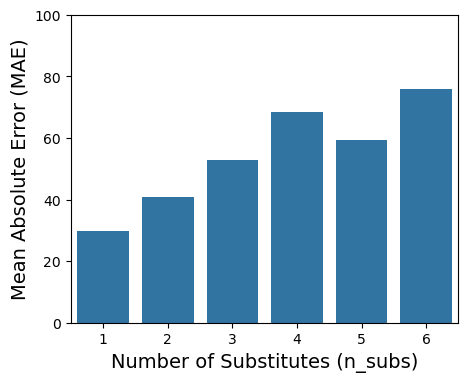

34/34 [==============================] - 0s 2ms/step
Fold 9/10
  Train MAE: 39.9835, Train RMSE: 58.1667, Train MAPE: 15.03%, Train R²: 0.7740
  Test  MAE: 65.4947, Test  RMSE: 86.3646, Test  MAPE: 22.36%, Test  R²: 0.5001
--------------------------------------------------------------------------------
Number of samples per n_subs (1-6): [ 5 16 16 21 19 41]
Mean Absolute Error per n_subs (1-6): [40.43245032 70.7817019  68.30238436 87.68107139 62.98017519 55.19370118]


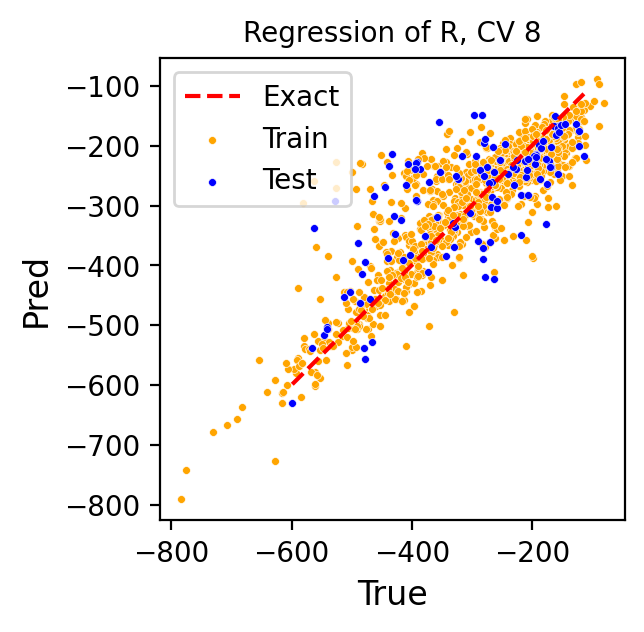

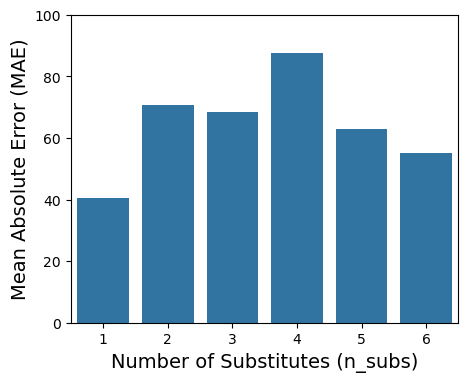

34/34 [==============================] - 0s 2ms/step
Fold 10/10
  Train MAE: 46.6063, Train RMSE: 64.4628, Train MAPE: 17.28%, Train R²: 0.7226
  Test  MAE: 55.4258, Test  RMSE: 73.4527, Test  MAPE: 21.26%, Test  R²: 0.6377
--------------------------------------------------------------------------------
Number of samples per n_subs (1-6): [ 6 18 18 20 20 35]
Mean Absolute Error per n_subs (1-6): [31.25133424 52.92226003 63.02086691 65.18756018 52.93287394 53.6290808 ]


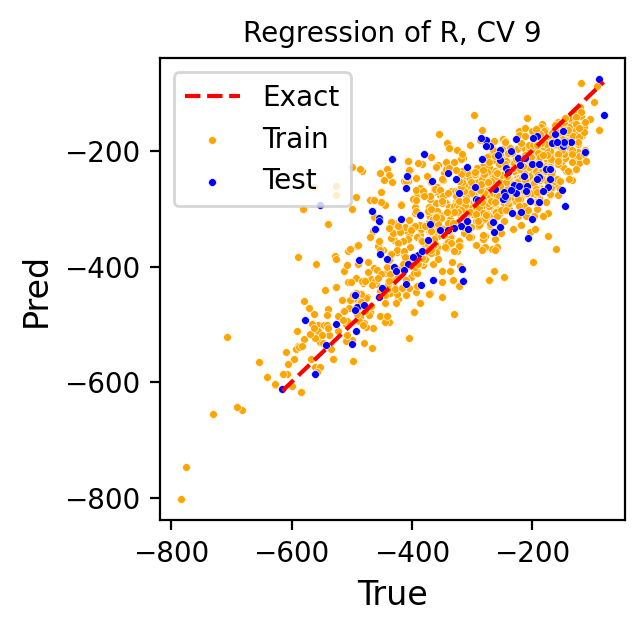

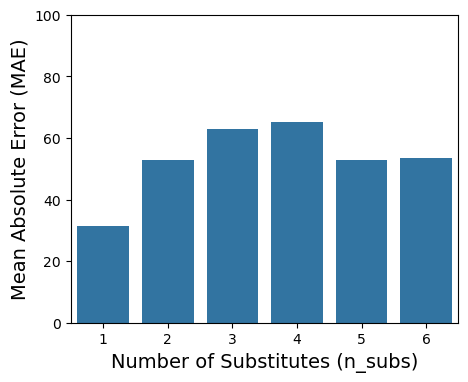

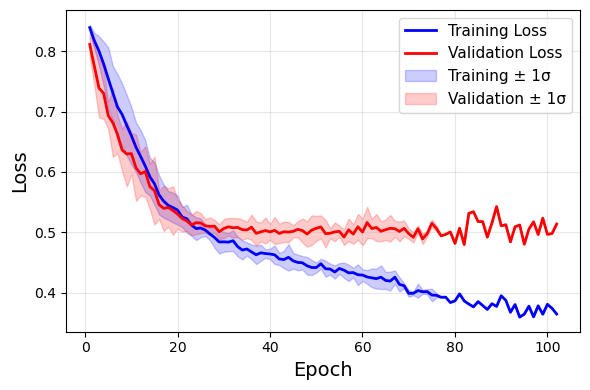


Rmin Loss Evolution Statistics:
Average final training loss: 0.425100 ± 0.026820
Average final validation loss: 0.511474 ± 0.014981
Average number of epochs: 61.8 ± 17.9
Average epoch of minimum validation loss: 41.8 ± 17.9
Minimum validation loss achieved: 0.462346


In [9]:
# Number of folds for cross-validation
n_crossvalidation = 10

# Initialize error accumulator for nsubs
error_nsubs_accu = np.zeros(6)  # Assuming there are 6 unique nsubs values

# Initialize metric arrays
test_mae_CV = np.zeros(n_crossvalidation)
test_rmse_CV = np.zeros(n_crossvalidation)
test_mape_CV = np.zeros(n_crossvalidation)
test_r2_CV = np.zeros(n_crossvalidation)
train_mae_CV = np.zeros(n_crossvalidation)
train_rmse_CV = np.zeros(n_crossvalidation)
train_mape_CV = np.zeros(n_crossvalidation)
train_r2_CV = np.zeros(n_crossvalidation)

# Initialize lists to store loss history from each fold
train_loss_histories = []
val_loss_histories = []

# Build the model once and save initial weights
best_model = build_model(best_hp)
initial_weights = best_model.get_weights()

from sklearn.model_selection import KFold

kf = KFold(n_splits=n_crossvalidation, shuffle=True, random_state=42)
for i_crossval, (train_idx, test_idx) in enumerate(kf.split(x_data)):
    x_train, x_test = x_data[train_idx], x_data[test_idx]
    y_train, y_test = y_data[train_idx], y_data[test_idx]

    # Reset model weights
    best_model.set_weights(initial_weights)
    
    # Setup callbacks: Reduce LR on plateau and EarlyStopping for final training
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-3)
    early_stop_final = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    # Train the model
    history = best_model.fit(
        x_train, y_train,
        epochs=400,
        batch_size=32,
        validation_split=0.1,
        callbacks=[reduce_lr, early_stop_final],
        verbose=0
    )
    
    # Store loss histories from this fold
    train_loss_histories.append(history.history['loss'])
    val_loss_histories.append(history.history['val_loss'])
    
    def invert_normalization(y_pred, y_true, mean, std):
        y_pred = y_pred * std + mean
        y_true = y_true * std + mean
        return y_pred.ravel(), y_true.ravel()

    # Evaluate metrics
    y_pred_test, y_true_test = invert_normalization(best_model.predict(x_test), y_test, Rmin_abs_mean, Rmin_abs_std)
    y_pred_train, y_true_train = invert_normalization(best_model.predict(x_train), y_train, Rmin_abs_mean, Rmin_abs_std)
    
    plot_PredvsTrue(y_true_test, y_pred_test, y_true_train, y_pred_train, i_CV=i_crossval)
    
    def calculate_metrics(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
        r2 = r2_score(y_true, y_pred)
        return mae, rmse, mape, r2
    
    test_mae, test_rmse, test_mape, test_r2 = calculate_metrics(y_true_test, y_pred_test)
    train_mae, train_rmse, train_mape, train_r2 = calculate_metrics(y_true_train, y_pred_train)
    
    # Save metrics
    test_mae_CV[i_crossval] = test_mae
    test_rmse_CV[i_crossval] = test_rmse
    test_mape_CV[i_crossval] = test_mape
    test_r2_CV[i_crossval] = test_r2
    train_mae_CV[i_crossval] = train_mae
    train_rmse_CV[i_crossval] = train_rmse
    train_mape_CV[i_crossval] = train_mape
    train_r2_CV[i_crossval] = train_r2

    # Print metrics for the current fold
    print(f"Fold {i_crossval + 1}/{n_crossvalidation}")
    print(f"  Train MAE: {train_mae:.4f}, Train RMSE: {train_rmse:.4f}, Train MAPE: {train_mape:.2f}%, Train R²: {train_r2:.4f}")
    print(f"  Test  MAE: {test_mae:.4f}, Test  RMSE: {test_rmse:.4f}, Test  MAPE: {test_mape:.2f}%, Test  R²: {test_r2:.4f}")
    print("-" * 80)

    # Compute error for different nsubs on the test set
    error_nsubs = error_vs_nsubs(x_test, y_pred_test, y_true_test)
    error_nsubs_accu = error_nsubs_accu + error_nsubs

# Compute mean error for each nsubs value across folds
error_nsubs_mean = error_nsubs_accu / n_crossvalidation

# ============================================================================
# PLOT LOSS EVOLUTION ACROSS FOLDS FOR RMIN
# ============================================================================

def plot_rmin_loss_evolution(train_losses, val_losses):
    """
    Plot the evolution of training and validation loss across epochs for Rmin model,
    averaging over all folds with confidence intervals.
    """
    import matplotlib.pyplot as plt
    
    # Find the maximum number of epochs across all folds
    max_epochs = max(len(loss) for loss in train_losses)
    
    # Pad shorter histories with NaN to align them
    train_losses_padded = []
    val_losses_padded = []
    
    for train_loss, val_loss in zip(train_losses, val_losses):
        train_padded = train_loss + [np.nan] * (max_epochs - len(train_loss))
        val_padded = val_loss + [np.nan] * (max_epochs - len(val_loss))
        train_losses_padded.append(train_padded)
        val_losses_padded.append(val_padded)
    
    # Convert to numpy arrays
    train_losses_array = np.array(train_losses_padded)
    val_losses_array = np.array(val_losses_padded)
    
    # Calculate mean and standard deviation (ignoring NaN values)
    train_mean = np.nanmean(train_losses_array, axis=0)
    train_std = np.nanstd(train_losses_array, axis=0)
    val_mean = np.nanmean(val_losses_array, axis=0)
    val_std = np.nanstd(val_losses_array, axis=0)
    
    # Create epoch array
    epochs = np.arange(1, max_epochs + 1)
    
    # Create the plot
    plt.figure(figsize=(6, 4))
    
    # Plot mean lines
    plt.plot(epochs, train_mean, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, val_mean, 'r-', label='Validation Loss', linewidth=2)
    
    # Add shaded regions for standard deviation
    plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, 
                     color='blue', alpha=0.2, label='Training ± 1σ')
    plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, 
                     color='red', alpha=0.2, label='Validation ± 1σ')
    
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Set y-axis to log scale if loss values vary significantly
    if np.max(train_mean) / np.min(train_mean[~np.isnan(train_mean)]) > 10:
        plt.yscale('log')
        plt.ylabel('Loss (log scale)', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics specific to Rmin
    print(f"\nRmin Loss Evolution Statistics:")
    print(f"Average final training loss: {np.nanmean([losses[-1] for losses in train_losses]):.6f} ± {np.nanstd([losses[-1] for losses in train_losses]):.6f}")
    print(f"Average final validation loss: {np.nanmean([losses[-1] for losses in val_losses]):.6f} ± {np.nanstd([losses[-1] for losses in val_losses]):.6f}")
    print(f"Average number of epochs: {np.mean([len(losses) for losses in train_losses]):.1f} ± {np.std([len(losses) for losses in train_losses]):.1f}")
    
    # Additional analysis for Rmin convergence
    min_val_loss_epochs = [np.argmin(losses) + 1 for losses in val_losses]
    print(f"Average epoch of minimum validation loss: {np.mean(min_val_loss_epochs):.1f} ± {np.std(min_val_loss_epochs):.1f}")
    print(f"Minimum validation loss achieved: {np.nanmin([np.min(losses) for losses in val_losses]):.6f}")

# Plot the loss evolution for Rmin
plot_rmin_loss_evolution(train_loss_histories, val_loss_histories)

# Resulting metrics from CV

In [11]:
# Define metric names
metrics = ["mae", "rmse", "mape", "r2"]

# Compute mean and standard deviation for each metric
results = {
    f"train_{metric}": (np.mean(eval(f"train_{metric}_CV")), np.std(eval(f"train_{metric}_CV")))
    for metric in metrics
}
results.update({
    f"test_{metric}": (np.mean(eval(f"test_{metric}_CV")), np.std(eval(f"test_{metric}_CV")))
    for metric in metrics
})

# Print results in formatted output
for metric in metrics:
    print(f"Train {metric.upper()}: {results[f'train_{metric}'][0]:.6f} ± {results[f'train_{metric}'][1]:.6f}")
    print(f"Test {metric.upper()}: {results[f'test_{metric}'][0]:.6f} ± {results[f'test_{metric}'][1]:.6f}")
    print()

Train MAE: 51.707108 ± 3.472761
Test MAE: 62.024329 ± 5.596867

Train RMSE: 70.008656 ± 3.966830
Test RMSE: 81.098536 ± 5.788325

Train MAPE: 18.798010 ± 1.068888
Test MAPE: 22.400145 ± 2.341815

Train R2: 0.671306 ± 0.039146
Test R2: 0.548391 ± 0.092522



# Mean MAE for substituent
With all the MAE values obtained for each substituent in each fold, will do the mean value.

n_subs = 0: MAE = 30.17
n_subs = 1: MAE = 54.87
n_subs = 2: MAE = 62.72
n_subs = 3: MAE = 68.06
n_subs = 4: MAE = 62.55
n_subs = 5: MAE = 63.16


'# Save Plot\nplt.savefig("mean_error_vs_nsubs.png", dpi=300, bbox_inches="tight")\nplt.show()'

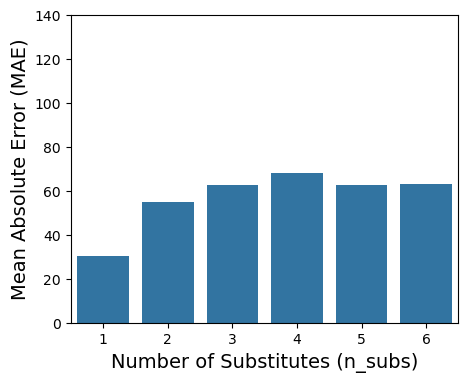

In [12]:
# Print formatted MAE values
for i, err in enumerate(error_nsubs_mean):
    print(f"n_subs = {i}: MAE = {err:.2f}")

# Enhanced Visualization
plt.figure(figsize=(5, 4))
sns.barplot(x=np.arange(1, 7), y=error_nsubs_mean)

plt.xlabel("Number of Substitutes (n_subs)", fontsize=14)
plt.ylabel("Mean Absolute Error (MAE)", fontsize=14)
plt.grid(False)
plt.ylim([0, 140])

"""# Save Plot
plt.savefig("mean_error_vs_nsubs.png", dpi=300, bbox_inches="tight")
plt.show()"""


# Traning of the final model
Train with all the available data to check model performance.

Epoch 1/1000
19/19 - 1s - loss: 0.8259 - lr: 0.0050 - 705ms/epoch - 37ms/step
Epoch 2/1000
19/19 - 0s - loss: 0.7207 - lr: 0.0050 - 110ms/epoch - 6ms/step
Epoch 3/1000
19/19 - 0s - loss: 0.6257 - lr: 0.0050 - 99ms/epoch - 5ms/step
Epoch 4/1000
19/19 - 0s - loss: 0.5754 - lr: 0.0050 - 99ms/epoch - 5ms/step
Epoch 5/1000
19/19 - 0s - loss: 0.5506 - lr: 0.0050 - 89ms/epoch - 5ms/step
Epoch 6/1000
19/19 - 0s - loss: 0.5468 - lr: 0.0050 - 87ms/epoch - 5ms/step
Epoch 7/1000
19/19 - 0s - loss: 0.5189 - lr: 0.0050 - 89ms/epoch - 5ms/step
Epoch 8/1000
19/19 - 0s - loss: 0.5138 - lr: 0.0050 - 88ms/epoch - 5ms/step
Epoch 9/1000
19/19 - 0s - loss: 0.5110 - lr: 0.0050 - 90ms/epoch - 5ms/step
Epoch 10/1000
19/19 - 0s - loss: 0.5084 - lr: 0.0050 - 84ms/epoch - 4ms/step
Epoch 11/1000
19/19 - 0s - loss: 0.5041 - lr: 0.0050 - 85ms/epoch - 4ms/step
Epoch 12/1000
19/19 - 0s - loss: 0.4973 - lr: 0.0050 - 82ms/epoch - 4ms/step
Epoch 13/1000
19/19 - 0s - loss: 0.4971 - lr: 0.0050 - 87ms/epoch - 5ms/step
Epoch

INFO:tensorflow:Assets written to: ./CV_Models/Rmin_model_CV\assets


INFO:tensorflow:Assets written to: ./CV_Models/Rmin_model_CV\assets


37/37 [==============================] - 0s 2ms/step

Final Model Metrics:
MAE: 23.444617
RMSE: 31.457618
MAPE: 8.546562
R2: 0.933903
dense_36/kernel:0 (5, 1)
dense_37/kernel:0 (5, 1)
dense_38/kernel:0 (5, 1)
dense_39/kernel:0 (5, 1)
dense_40/kernel:0 (5, 1)
dense_41/kernel:0 (5, 1)
dense_42/kernel:0 (5, 1)
dense_43/kernel:0 (5, 1)
dense_44/kernel:0 (16, 256)
dense_44/bias:0 (256,)
dense_45/kernel:0 (256, 256)
dense_45/bias:0 (256,)
dense_46/kernel:0 (256, 256)
dense_46/bias:0 (256,)
dense_47/kernel:0 (256, 1)
dense_47/bias:0 (1,)

Pos0: [  14.677908 -138.47566   -83.83969   -66.194305 -216.52237 ]
Pos1: [-24.32817   55.601475  69.55765  105.5212   173.46873 ]
Pos2: [-18.31545  -94.65589   60.75361   81.24948   96.482796]
Pos3: [  10.720266  -46.88132   -28.35766  -106.22869  -179.86577 ]
Pos4: [-13.373209  12.362848  51.526024  74.95825  170.91606 ]
Pos5: [-16.889141  40.923996  76.21602   94.69064  158.61089 ]
Pos6: [  16.16958   -28.5775    -82.26942   -95.556755 -153.9489  ]
Pos7: 

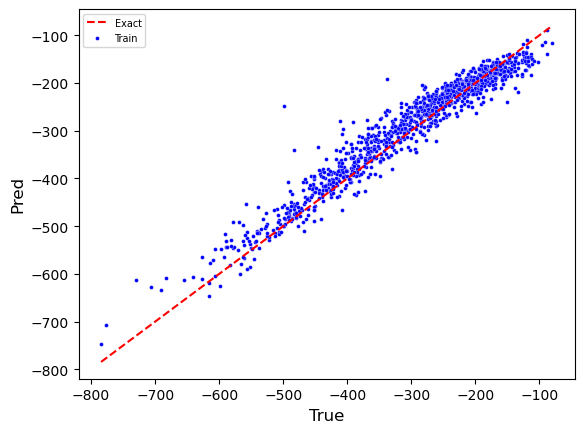

In [13]:
import os

# Ensure the directory exists
os.makedirs('./CV_Models/', exist_ok=True)

# Reinitialize the model
best_model = build_model(best_hp)

'''# Use a fixed learning rate for stability
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
best_model.compile(optimizer=optimizer, loss='mean_absolute_error')

# Train the model with smaller batch size and fixed validation set
x_train, x_val, y_train, y_val = train_test_split(x_data, y_data, test_size=0.1, random_state=42)
'''
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

history = best_model.fit(
    x_data, y_data,
    #validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=64,
    verbose=2,
    callbacks=[early_stop, reduce_lr]
)

# Save the model in the SavedModel format
best_model.save('./CV_Models/Rmin_model_CV')

# Predict and invert normalization
y_pred_data = best_model.predict(x_data).ravel() * Rmin_abs_std + Rmin_abs_mean
y_true_data = y_data.ravel() * Rmin_abs_std + Rmin_abs_mean

# Compute final metrics
final_metrics = {
    "mae": mean_absolute_error(y_true_data, y_pred_data),
    "rmse": np.sqrt(mean_squared_error(y_true_data, y_pred_data)),
    "mape": mean_absolute_percentage_error(y_true_data, y_pred_data) * 100,
    "r2": r2_score(y_true_data, y_pred_data)
}

# Save final metrics
with open("final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=4)

# Print final metrics
print("\nFinal Model Metrics:")
for metric, value in final_metrics.items():
    print(f"{metric.upper()}: {value:.6f}")

# Improved Axis Scaling
p1 = min(y_true_data)
p2 = max(y_true_data)
plt.plot([p1, p2], [p1, p2], 'r--', label="Exact")

# Scatter Plots
sns.scatterplot(x=y_true_data, y=y_pred_data, color="blue", s=8, label="Train")

plt.xlabel("True", fontsize=12)
plt.ylabel("Pred", fontsize=12)
plt.legend(loc="upper left", fontsize=7)
plt.grid(False)

# 1-body coefficients
names = [weight.name for layer in best_model.layers for weight in layer.weights]
weights = best_model.get_weights()
for name, weight in zip(names, weights):
    print(name, weight.shape)
print()
for i in range(8):
    print('Pos'+str(i)+': '+str(weights[i].flatten()*Rmin_abs_std))